# **Bar Charts**

In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.

## Objectives

In this lab you will perform the following:

-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data

## Setup: Working with the Database
**Install the needed libraries**

In [1]:
#!pip install pandas
#!pip install matplotlib

**Download and connect to the database file containing survey data.**

To start, download and load the dataset into a `pandas` DataFrame.

In [4]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(url)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions

##### 1. Histogram of `ConvertedCompYearly`

Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.

In [5]:
# Select the compensation column and remove missing values

comp_df = df[['ConvertedCompYearly']].dropna()

# Convert to numeric

comp_df['ConvertedCompYearly'] = pd.to_numeric(
    comp_df['ConvertedCompYearly'],
    errors='coerce'
)

comp_df = comp_df.dropna()

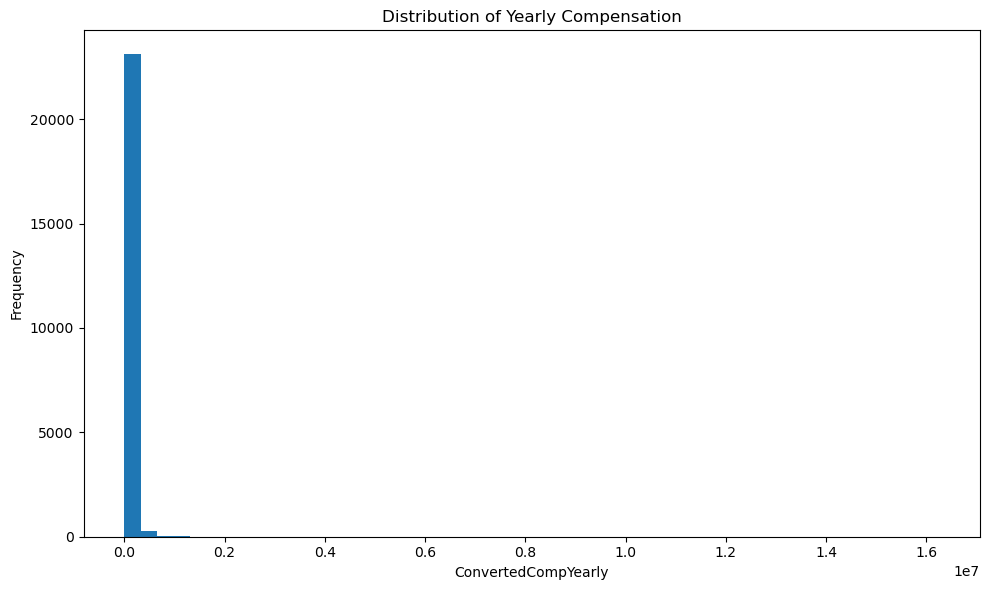

In [6]:
# Plot histogram

plt.figure(figsize=(10,6))

plt.hist(
    comp_df['ConvertedCompYearly'],
    bins=50
)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

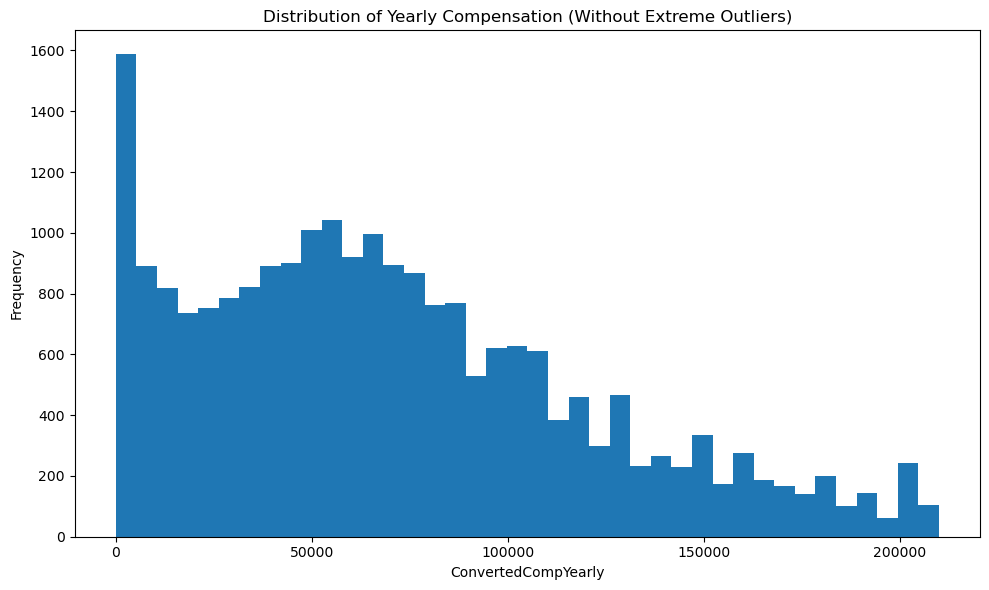

In [7]:
# Remove top 5% outliers

upper_limit = comp_df['ConvertedCompYearly'].quantile(0.95)

filtered_comp = comp_df[
    comp_df['ConvertedCompYearly'] <= upper_limit
]

plt.figure(figsize=(10,6))

plt.hist(
    filtered_comp['ConvertedCompYearly'],
    bins=40
)

plt.title('Distribution of Yearly Compensation (Without Extreme Outliers)')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`

Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.

In [8]:
# Check unique age groups

print(df['Age'].unique())

['Under 18 years old' '35-44 years old' '45-54 years old'
 '18-24 years old' '25-34 years old' '55-64 years old' 'Prefer not to say'
 '65 years or older']


In [9]:
# Age group mapping

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# Create numeric age column

age_df = df[['Age']].copy()

age_df['AgeNumeric'] = age_df['Age'].map(age_mapping)

# Remove missing values

age_df = age_df.dropna(subset=['AgeNumeric'])

age_df.head()

,Age,AgeNumeric
0,Under 18 years old,17.0
1,35-44 years old,40.0
2,45-54 years old,50.0
3,18-24 years old,21.0
4,18-24 years old,21.0


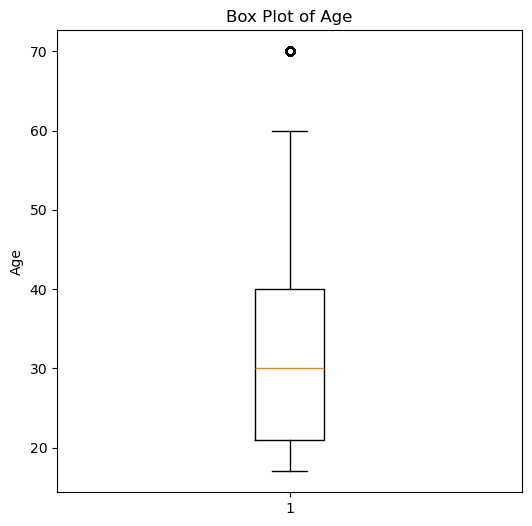

In [10]:
plt.figure(figsize=(6,6))

plt.boxplot(age_df['AgeNumeric'])

plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.show()

### Task 2: Visualizing Relationships in Data

##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`

Explore the relationship between age and compensation.

In [11]:
# Create age mapping

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# Select required columns

scatter_df = df[['Age', 'ConvertedCompYearly']].copy()

# Convert Age to numeric

scatter_df['Age_numeric'] = scatter_df['Age'].map(age_mapping)

# Convert compensation to numeric

scatter_df['ConvertedCompYearly'] = pd.to_numeric(
    scatter_df['ConvertedCompYearly'],
    errors='coerce'
)

# Remove missing values

scatter_df = scatter_df.dropna(
    subset=['Age_numeric', 'ConvertedCompYearly']
)

scatter_df.head()

,Age,ConvertedCompYearly,Age_numeric
72,18-24 years old,7322.0,21.0
374,25-34 years old,30074.0,30.0
379,35-44 years old,91295.0,40.0
385,35-44 years old,53703.0,40.0
389,25-34 years old,110000.0,30.0


In [12]:
upper_limit = scatter_df['ConvertedCompYearly'].quantile(0.95)

scatter_df = scatter_df[
    scatter_df['ConvertedCompYearly'] <= upper_limit
]

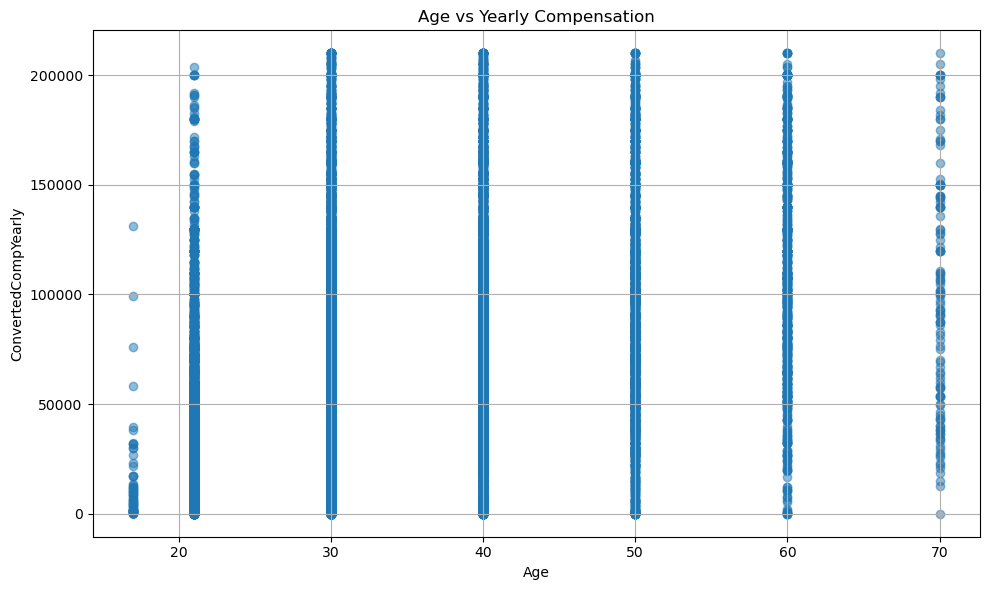

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    scatter_df['Age_numeric'],
    scatter_df['ConvertedCompYearly'],
    alpha=0.5
)

plt.title('Age vs Yearly Compensation')
plt.xlabel('Age')
plt.ylabel('ConvertedCompYearly')

plt.grid(True)

plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size

Explore how compensation and job satisfaction are related, with age as the bubble size.

In [14]:
# Age mapping

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# Select required columns

bubble_df = df[
    ['Age', 'ConvertedCompYearly', 'JobSatPoints_6']
].copy()

# Convert Age to numeric

bubble_df['Age_numeric'] = bubble_df['Age'].map(age_mapping)

# Convert columns to numeric

bubble_df['ConvertedCompYearly'] = pd.to_numeric(
    bubble_df['ConvertedCompYearly'],
    errors='coerce'
)

bubble_df['JobSatPoints_6'] = pd.to_numeric(
    bubble_df['JobSatPoints_6'],
    errors='coerce'
)

# Remove missing values

bubble_df = bubble_df.dropna(
    subset=[
        'Age_numeric',
        'ConvertedCompYearly',
        'JobSatPoints_6'
    ]
)

bubble_df.head()

,Age,ConvertedCompYearly,JobSatPoints_6,Age_numeric
72,18-24 years old,7322.0,65.0,21.0
379,35-44 years old,91295.0,0.0,40.0
389,25-34 years old,110000.0,20.0,30.0
392,35-44 years old,161044.0,30.0,40.0
398,45-54 years old,195000.0,30.0,50.0


In [15]:
upper_limit = bubble_df['ConvertedCompYearly'].quantile(0.95)

bubble_df = bubble_df[
    bubble_df['ConvertedCompYearly'] <= upper_limit
]

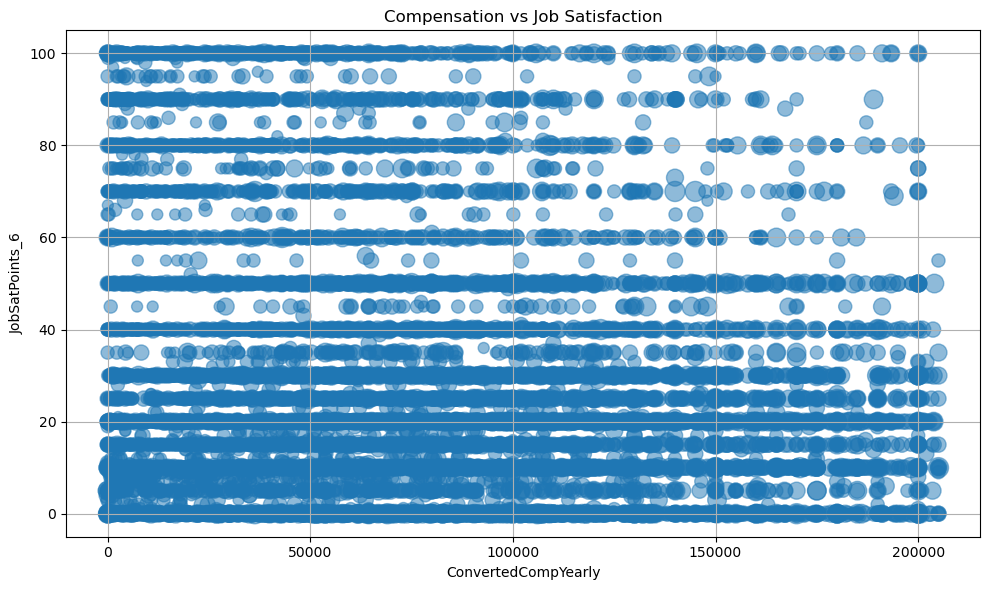

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(
    bubble_df['ConvertedCompYearly'],
    bubble_df['JobSatPoints_6'],
    s=bubble_df['Age_numeric'] * 3,   # Bubble size based on age
    alpha=0.5
)

plt.title('Compensation vs Job Satisfaction')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSatPoints_6')

plt.grid(True)

plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts

##### 1. Horizontal Bar Chart of `MainBranch` Distribution

Visualize the distribution of respondents’ primary roles to understand their professional focus.

In [17]:
# Count occurrences of each MainBranch category

mainbranch_counts = (
    df['MainBranch']
    .value_counts()
)

print(mainbranch_counts)

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64


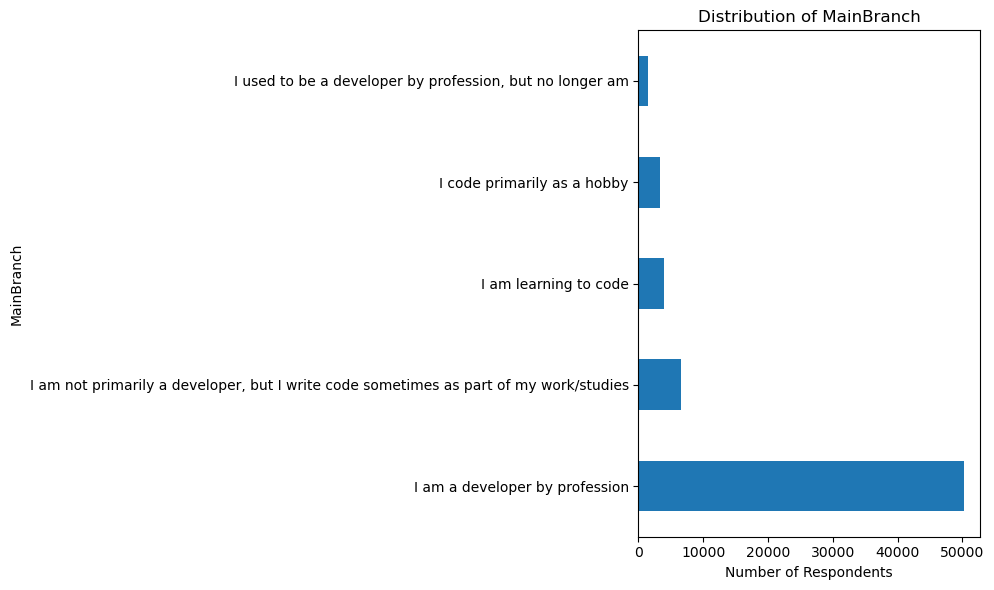

In [18]:
plt.figure(figsize=(10,6))

mainbranch_counts.plot(
    kind='barh'
)

plt.title('Distribution of MainBranch')
plt.xlabel('Number of Respondents')
plt.ylabel('MainBranch')

plt.tight_layout()
plt.show()

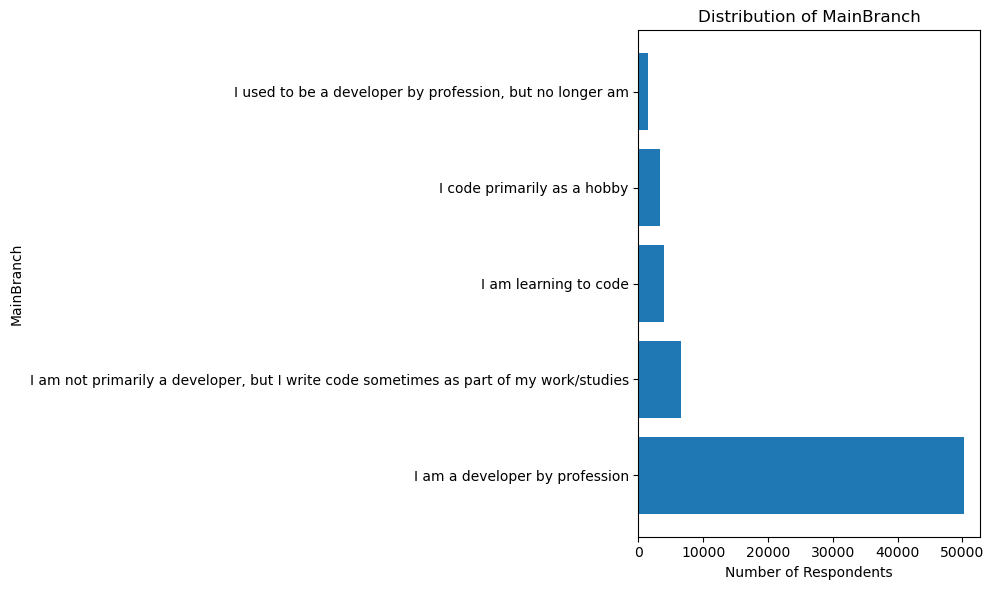

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    mainbranch_counts.index,
    mainbranch_counts.values
)

plt.title('Distribution of MainBranch')
plt.xlabel('Number of Respondents')
plt.ylabel('MainBranch')

plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With

Identify the most desired programming languages based on `LanguageWantToWorkWith`.

In [20]:
# Remove missing values

lang_df = df[['LanguageWantToWorkWith']].dropna()

# Split multiple languages into separate rows

lang_exploded = lang_df.assign(
    LanguageWantToWorkWith=
    lang_df['LanguageWantToWorkWith'].str.split(';')
).explode('LanguageWantToWorkWith')

# Count languages

top_languages = (
    lang_exploded['LanguageWantToWorkWith']
    .value_counts()
    .head(5)
)

print(top_languages)

LanguageWantToWorkWith
Python        25047
JavaScript    23774
SQL           22400
HTML/CSS      20721
TypeScript    20239
Name: count, dtype: int64


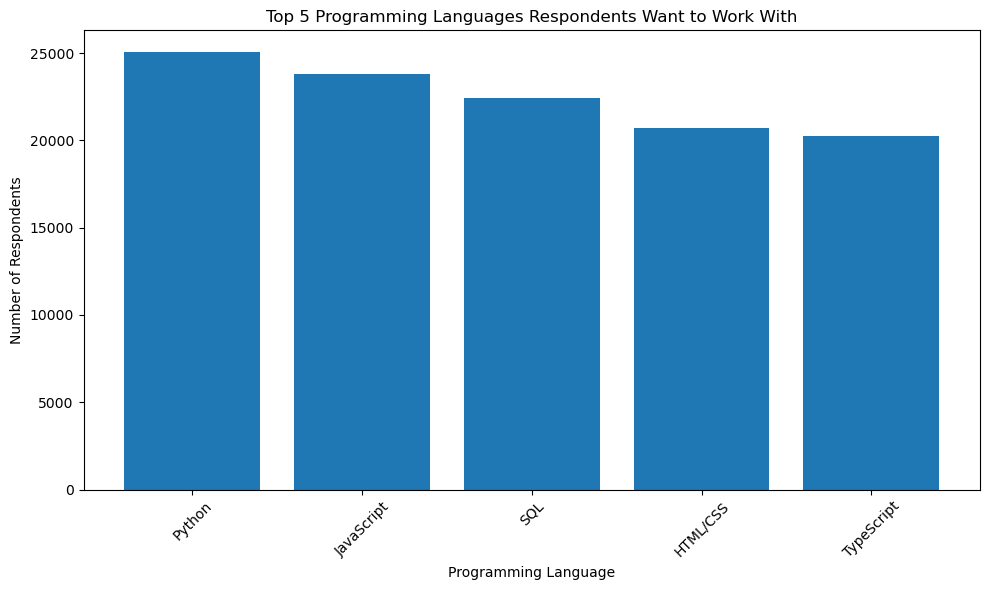

In [21]:
plt.figure(figsize=(10,6))

plt.bar(
    top_languages.index,
    top_languages.values
)

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

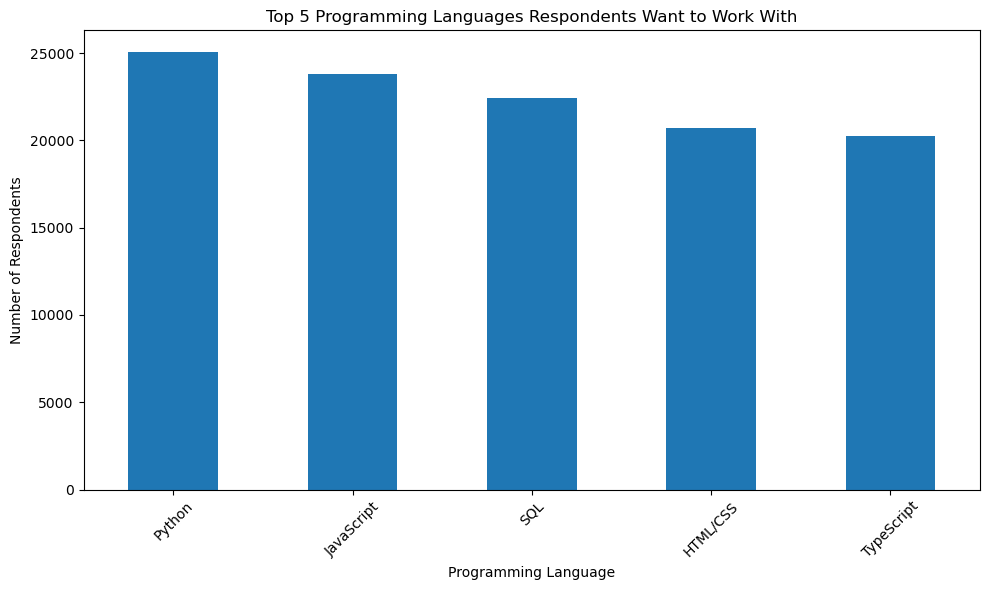

In [22]:
top_languages.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group

Compare job satisfaction metrics across different age groups with a stacked bar chart.

In [23]:
# Select required columns

jobsat_df = df[
    ['Age', 'JobSatPoints_6', 'JobSatPoints_7']
].dropna()

jobsat_df.head()

,Age,JobSatPoints_6,JobSatPoints_7
1,35-44 years old,0.0,0.0
10,35-44 years old,25.0,10.0
12,35-44 years old,30.0,0.0
15,45-54 years old,0.0,0.0
18,25-34 years old,60.0,10.0


In [24]:
jobsat_df['JobSatPoints_6'] = pd.to_numeric(
    jobsat_df['JobSatPoints_6'],
    errors='coerce'
)

jobsat_df['JobSatPoints_7'] = pd.to_numeric(
    jobsat_df['JobSatPoints_7'],
    errors='coerce'
)

jobsat_df = jobsat_df.dropna()

In [25]:
median_jobsat = (
    jobsat_df
    .groupby('Age')[
        ['JobSatPoints_6', 'JobSatPoints_7']
    ]
    .median()
)

print(median_jobsat)

                    JobSatPoints_6  JobSatPoints_7
Age                                               
18-24 years old               15.0            20.0
25-34 years old               20.0            15.0
35-44 years old               20.0            15.0
45-54 years old               20.0            15.0
55-64 years old               20.0            20.0
65 years or older             20.0            15.0
Prefer not to say             10.0             7.0
Under 18 years old             1.5             5.0


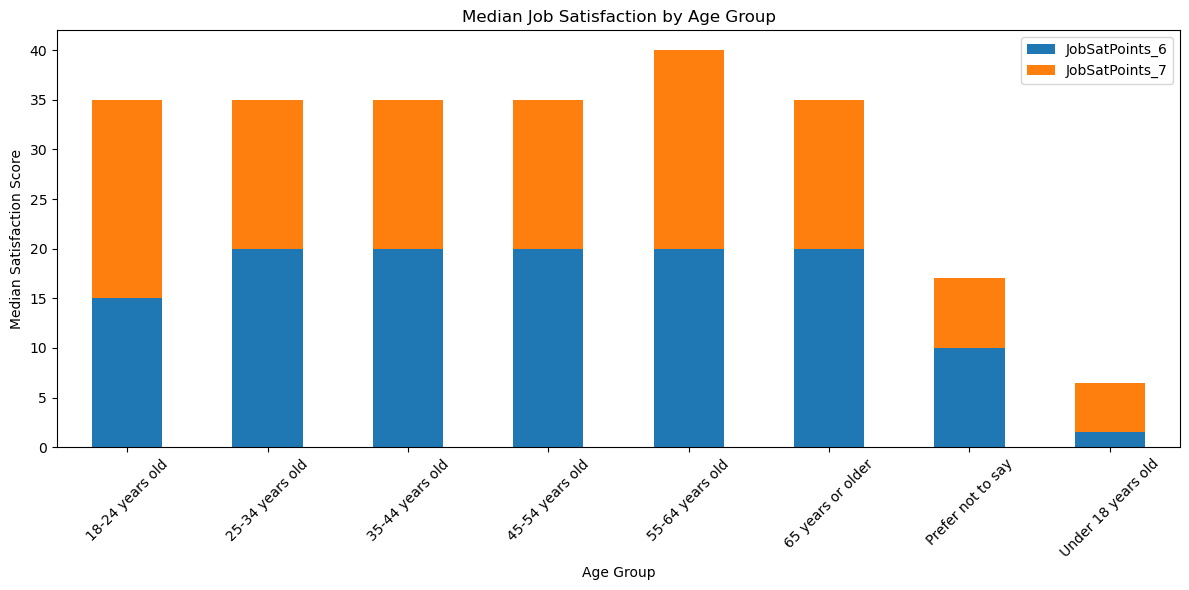

In [26]:
median_jobsat.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Median Job Satisfaction by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Satisfaction Score')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)

Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.

In [27]:
# Select non-null values

db_df = df[['DatabaseHaveWorkedWith']].dropna()

# Split multiple databases into separate rows

db_exploded = db_df.assign(
    DatabaseHaveWorkedWith=
    db_df['DatabaseHaveWorkedWith'].str.split(';')
).explode('DatabaseHaveWorkedWith')

# Count database usage

database_counts = (
    db_exploded['DatabaseHaveWorkedWith']
    .value_counts()
    .head(10)      # Top 10 databases
)

print(database_counts)

DatabaseHaveWorkedWith
PostgreSQL              25536
MySQL                   21099
SQLite                  17365
Microsoft SQL Server    13275
MongoDB                 13007
Redis                   10463
MariaDB                  8991
Elasticsearch            6533
Oracle                   5273
Dynamodb                 4138
Name: count, dtype: int64


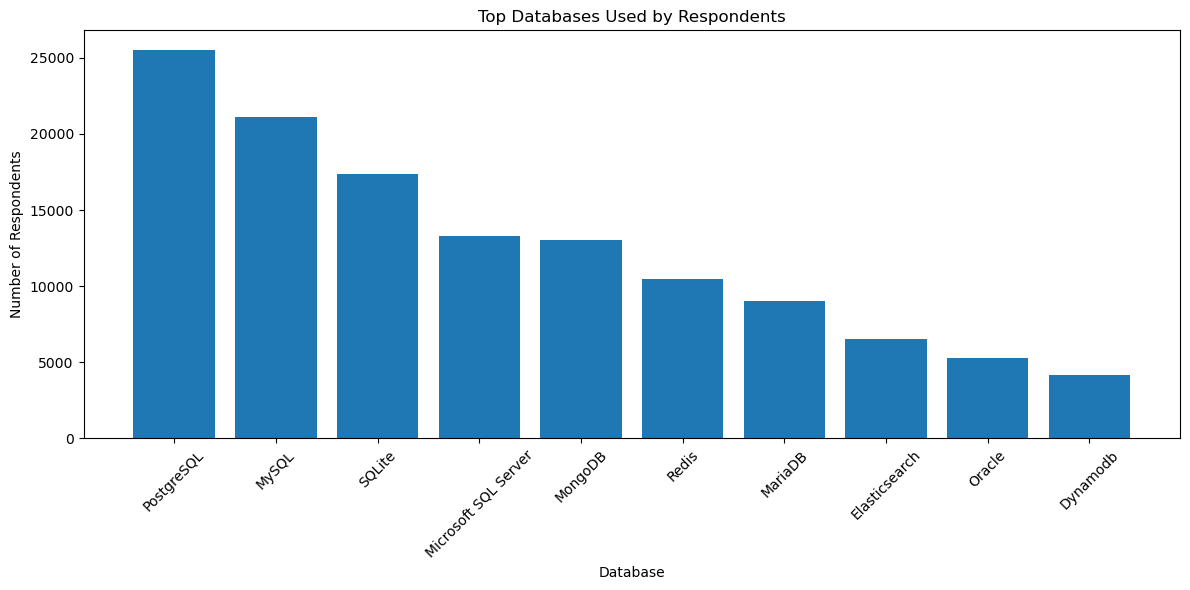

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    database_counts.index,
    database_counts.values
)

plt.title('Top Databases Used by Respondents')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

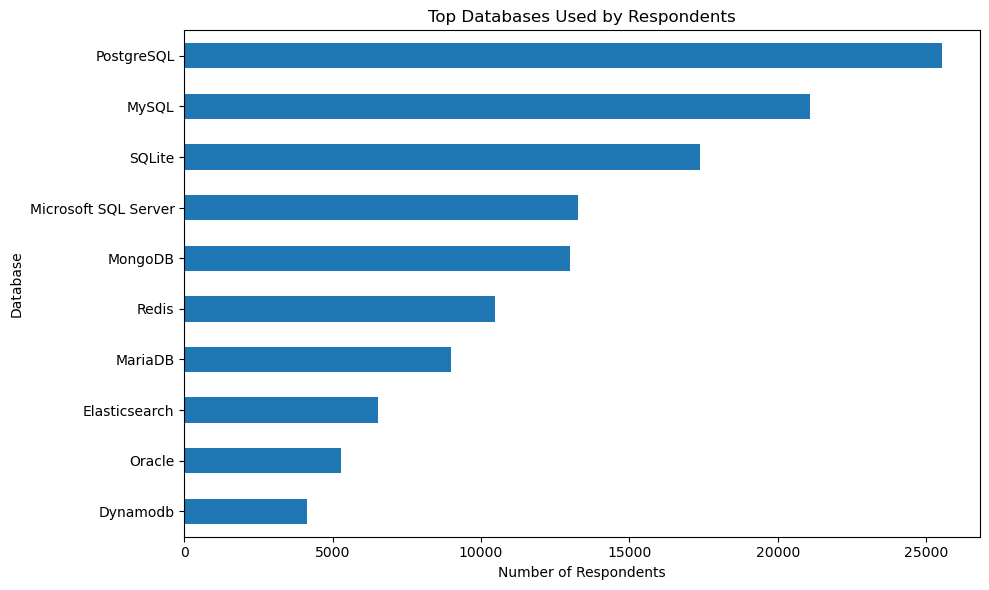

In [29]:
database_counts.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top Databases Used by Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Database')

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts

##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups

Compare median compensation across multiple age groups with a grouped bar chart.

In [30]:
# Select required columns

comp_df = df[
    ['Age', 'ConvertedCompYearly']
].dropna()

# Convert compensation to numeric

comp_df['ConvertedCompYearly'] = pd.to_numeric(
    comp_df['ConvertedCompYearly'],
    errors='coerce'
)

comp_df = comp_df.dropna()

In [31]:
median_comp = (
    comp_df
    .groupby('Age')['ConvertedCompYearly']
    .median()
    .sort_values()
)

print(median_comp)

Age
Under 18 years old      7626.5
18-24 years old        25000.0
25-34 years old        59825.0
35-44 years old        84796.0
45-54 years old        99099.0
65 years or older     106000.0
55-64 years old       109691.0
Prefer not to say     140000.0
Name: ConvertedCompYearly, dtype: float64


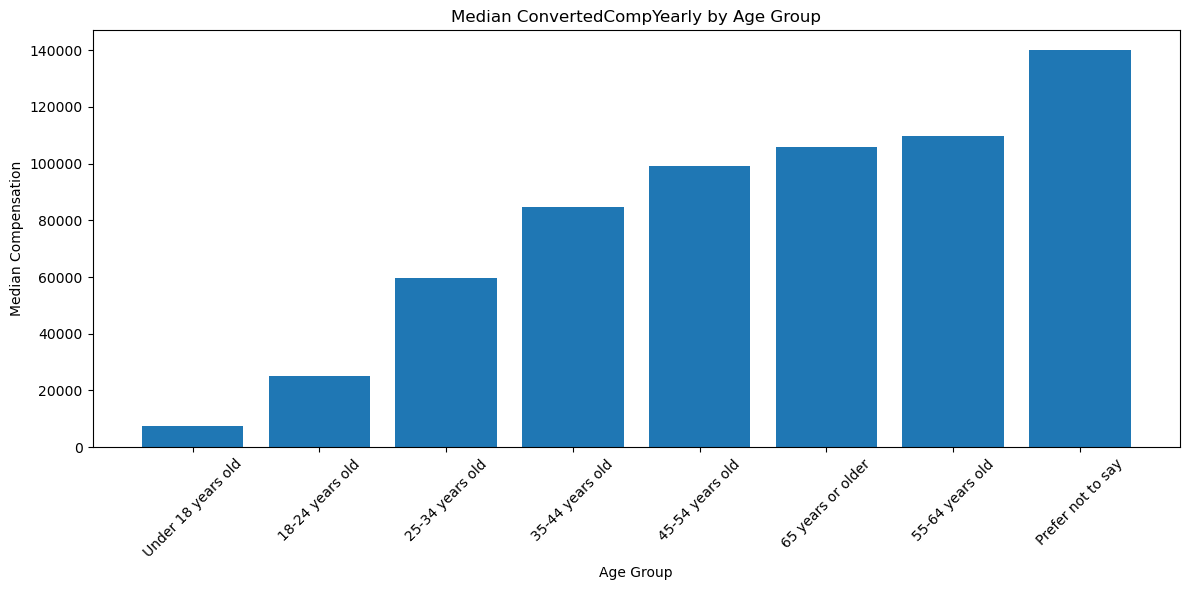

In [32]:
plt.figure(figsize=(12,6))

plt.bar(
    median_comp.index,
    median_comp.values
)

plt.title('Median ConvertedCompYearly by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

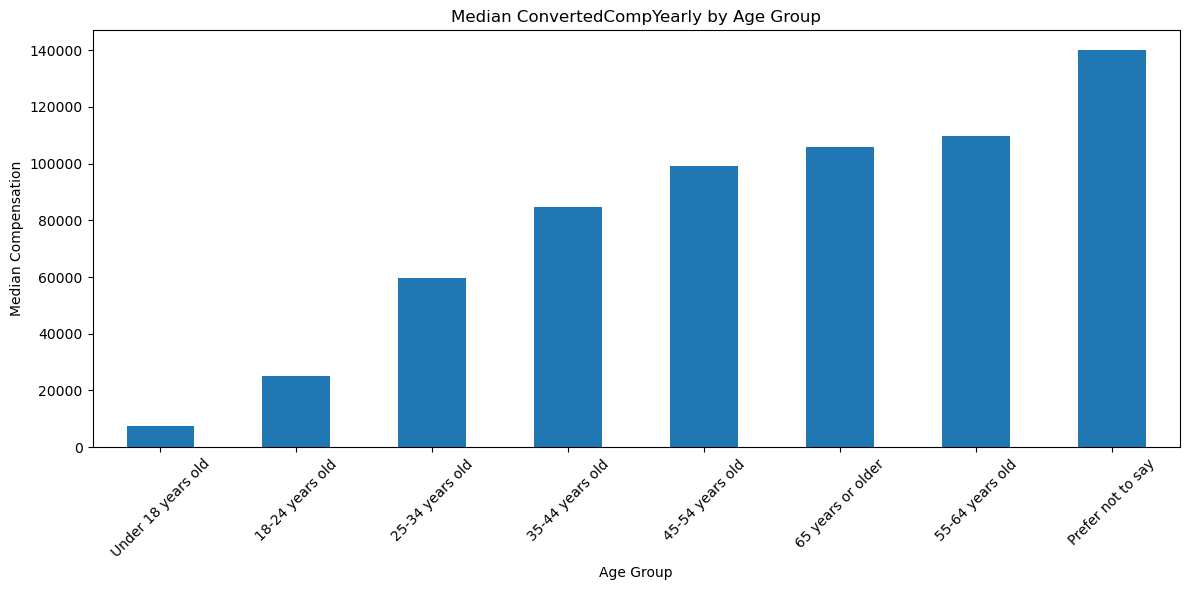

In [33]:
median_comp.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Median ConvertedCompYearly by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country

Show the distribution of respondents by country to see which regions are most represented.

In [34]:
# Count respondents by country

country_counts = (
    df['Country']
    .dropna()
    .value_counts()
    .head(10)      # Top 10 countries
)

print(country_counts)

Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Name: count, dtype: int64


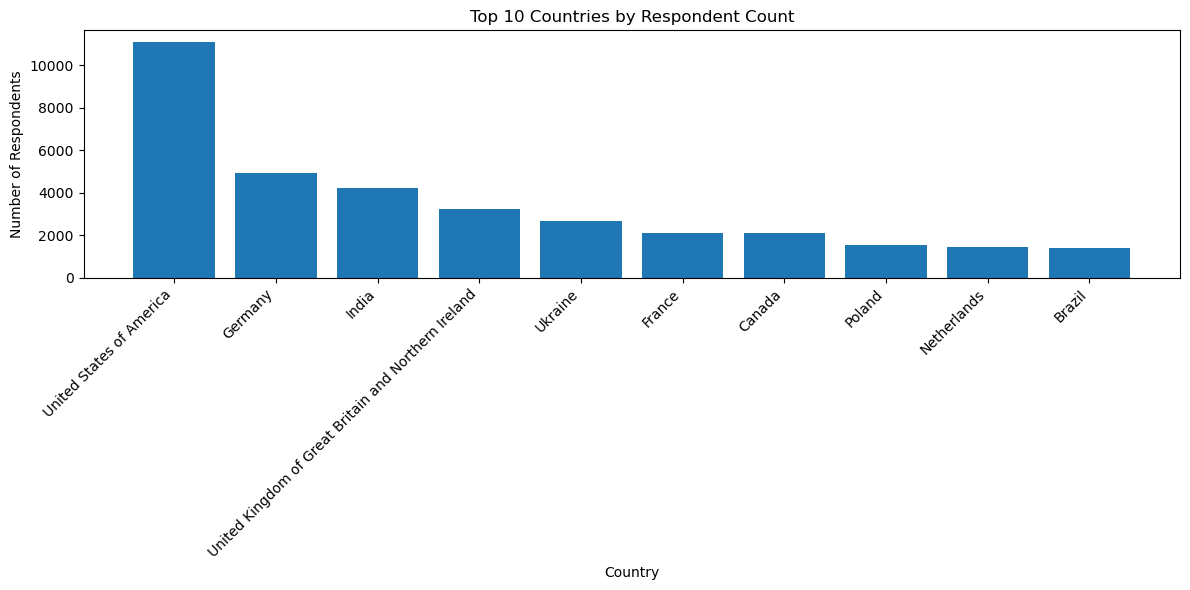

In [35]:
plt.figure(figsize=(12,6))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

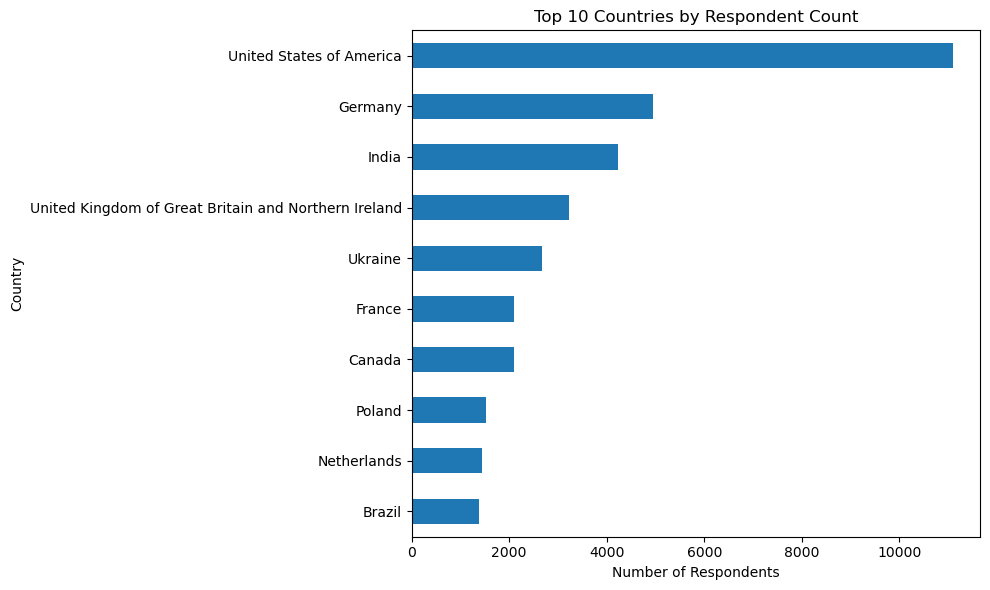

In [36]:
country_counts.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### Final Step: Review

This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.

## Summary

After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.